In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/clean_investor_transactions.csv")

print(df.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [5]:
print(df['age_group'].unique())

age_analysis = df.groupby('age_group')['amount_inr'].sum().reset_index()
print(age_analysis)

age_order = ['18-25', '26-35', '36-45', '46-55', '56+']

df['age_group'] = pd.Categorical(
    df['age_group'],
    categories=age_order,
    ordered=True
)

['56+' '18-25' '36-45' '26-35' '46-55']
  age_group  amount_inr
0     18-25   531639392
1     26-35  1451600218
2     36-45   871647528
3     46-55   405406469
4       56+   261286823


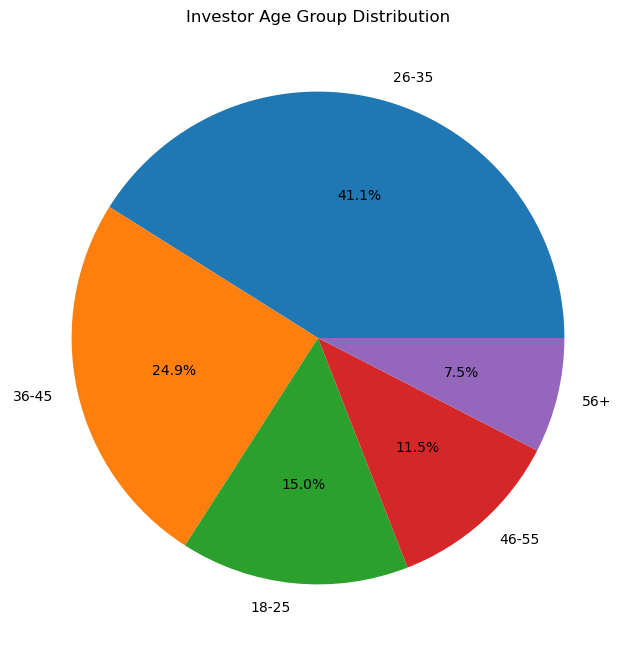

In [7]:
age_counts = df['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")

plt.show()

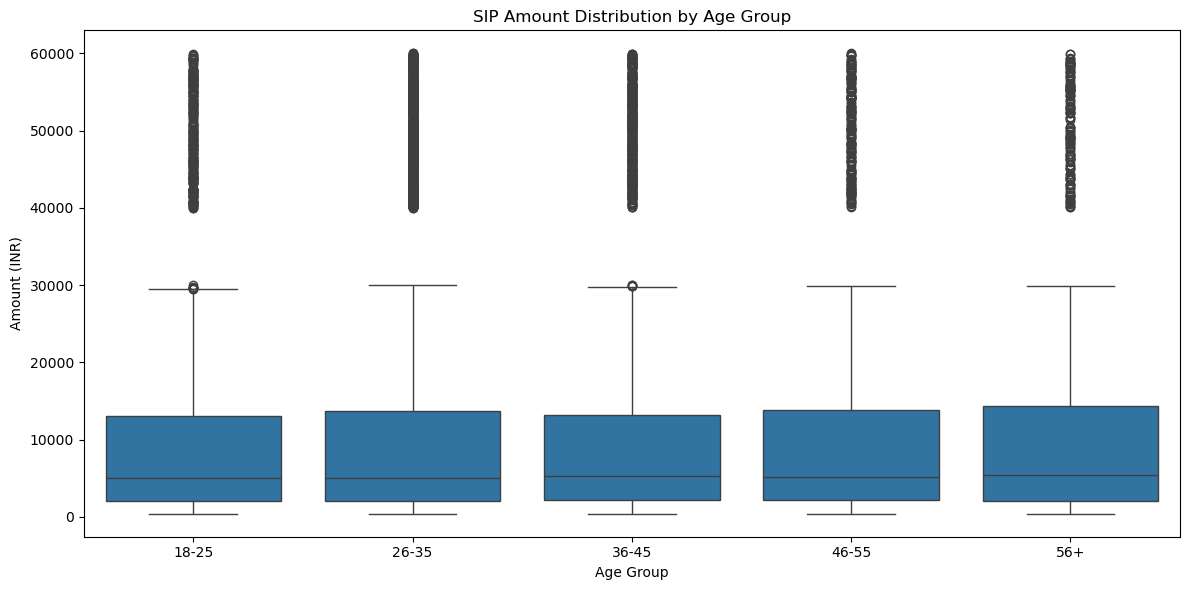

In [9]:
sip_df = df[df['transaction_type'] == 'SIP']

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='age_group',
    y='amount_inr',        # ← fixed
    data=sip_df,
    order=['18-25', '26-35', '36-45', '46-55', '56+']  # proper age order
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/clean_investor_transactions.csv")

sip_df = df[df['transaction_type'] == 'SIP']

print(df.columns.tolist())
print(df.head(2))

state_sip = sip_df.groupby('state')['amount_inr'].sum()

state_sip = state_sip.sort_values()

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   

       state       city city_tier age_group  gender  annual_income_lakh  \
0  Telangana  Hyderabad       T30       56+  Female                77.1   
1     Punjab   Amritsar       B30     18-25    Male                 7.1   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  


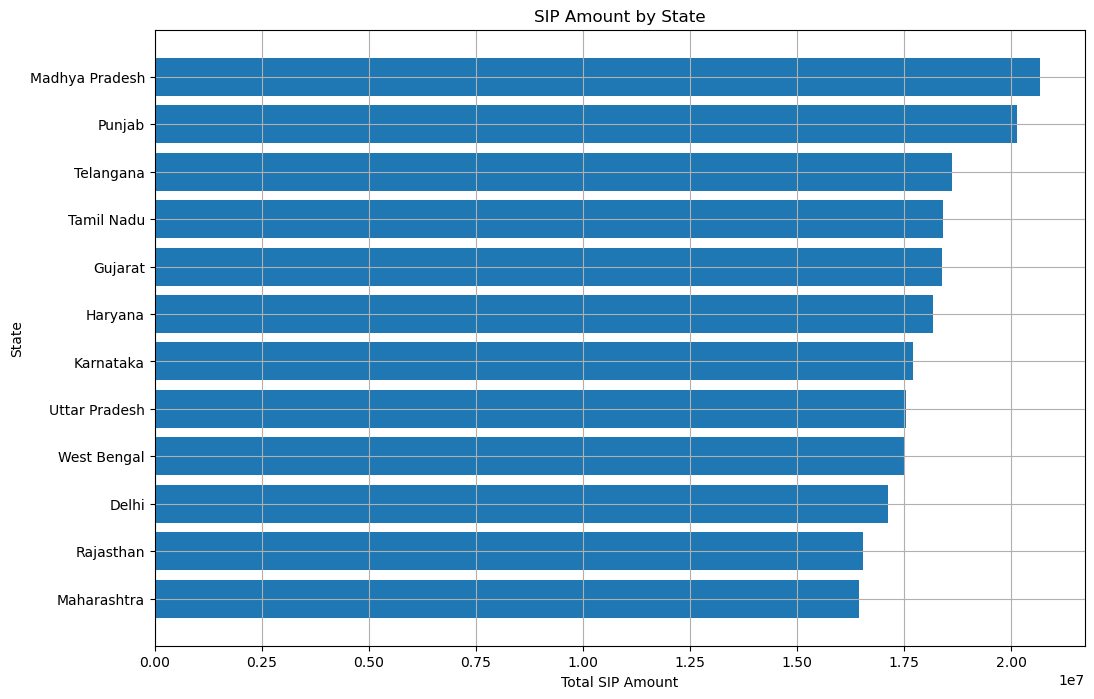

In [6]:
plt.figure(figsize=(12,8))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount")
plt.ylabel("State")

plt.grid(True)

plt.show()

In [12]:
city_tier = sip_df.groupby(
    'city_tier'
)['amount_inr'].sum()

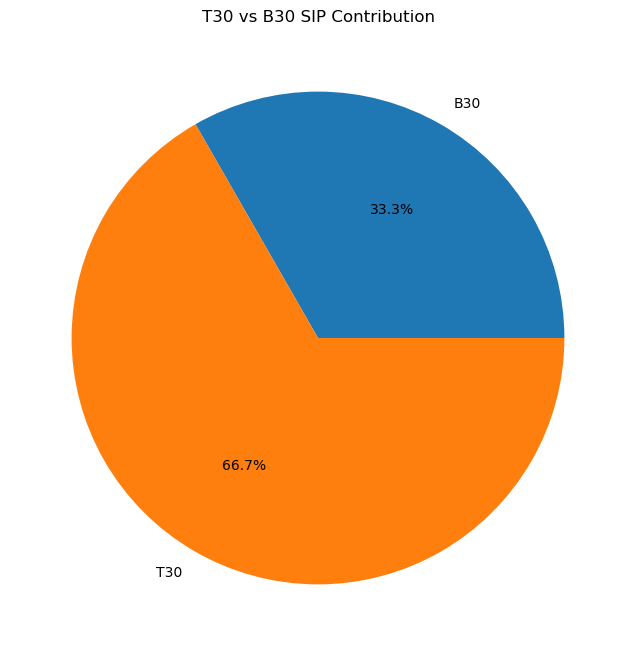

In [13]:
plt.figure(figsize=(8,8))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 SIP Contribution")

plt.show()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

equity_df = df.copy()

print(df.info)
sector_distribution = equity_df.groupby(
    'sector'
)['weight_pct'].sum()

<bound method DataFrame.info of      amfi_code stock_symbol                 stock_name       sector  \
0       119551    POWERGRID     Power Grid Corporation    Utilities   
1       119551     HDFCBANK              HDFC Bank Ltd      Banking   
2       119551       GRASIM      Grasim Industries Ltd  Diversified   
3       119551      DRREDDY   Dr. Reddy's Laboratories       Pharma   
4       119551   ASIANPAINT           Asian Paints Ltd       Paints   
..         ...          ...                        ...          ...   
317     149324     DIVISLAB        Divi's Laboratories       Pharma   
318     149324   BHARTIARTL          Bharti Airtel Ltd      Telecom   
319     149324          TCS  Tata Consultancy Services           IT   
320     149324   INDUSINDBK          IndusInd Bank Ltd      Banking   
321     149324         NTPC                   NTPC Ltd    Utilities   

     weight_pct  market_value_cr  current_price_inr portfolio_date  
0         13.85           737.09            60

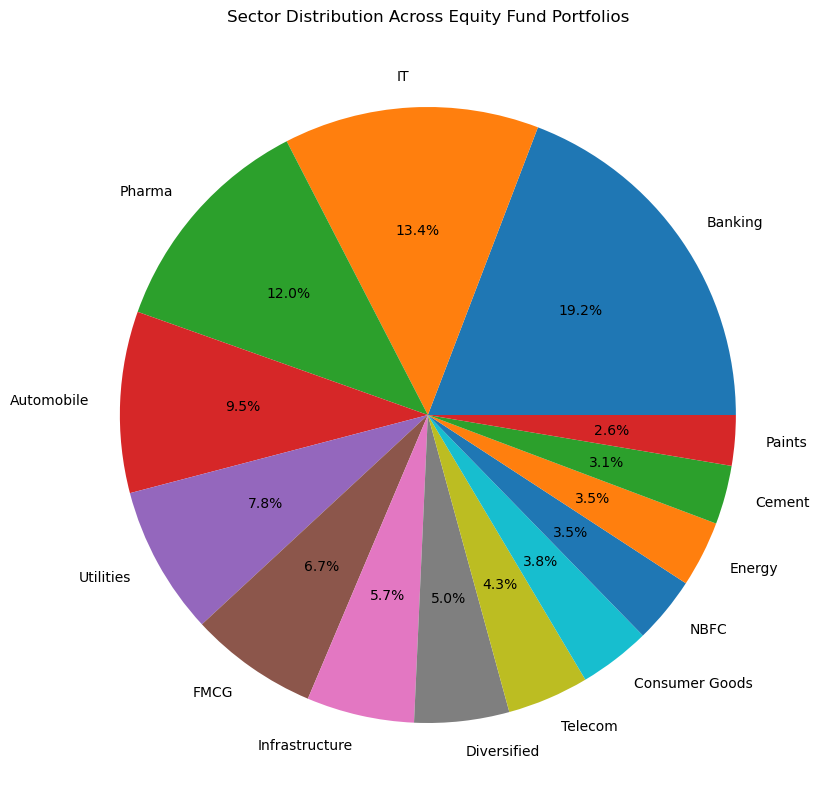

In [23]:
sector_distribution = sector_distribution.sort_values(
    ascending=False
)
plt.figure(figsize=(10,10))

plt.pie(
    sector_distribution,
    labels=sector_distribution.index,
    autopct='%1.1f%%'
)

plt.title("Sector Distribution Across Equity Fund Portfolios")

plt.show()

ADVANCED RISK ANALYTICS


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

df['date'] = pd.to_datetime(
    df['date']
)

df = df.sort_values(
    ['amfi_code', 'date']
)

df['daily_return'] = df.groupby(
    'amfi_code'
)['nav'].pct_change()

df = df.dropna(
    subset=['daily_return']
)

risk_metrics = []

for code in df['amfi_code'].unique():

    temp = df[
        df['amfi_code'] == code
    ]

    returns = temp['daily_return']

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    risk_metrics.append({
        'amfi_code': code,
        'VaR_95': var_95,
        'CVaR_95': cvar_95
    })

risk_df = pd.DataFrame(
    risk_metrics
)

print(risk_df.head())



   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


In [8]:
risk_df.to_csv(
    "../data/processed/var_cvar_metrics.csv",
    index=False
)

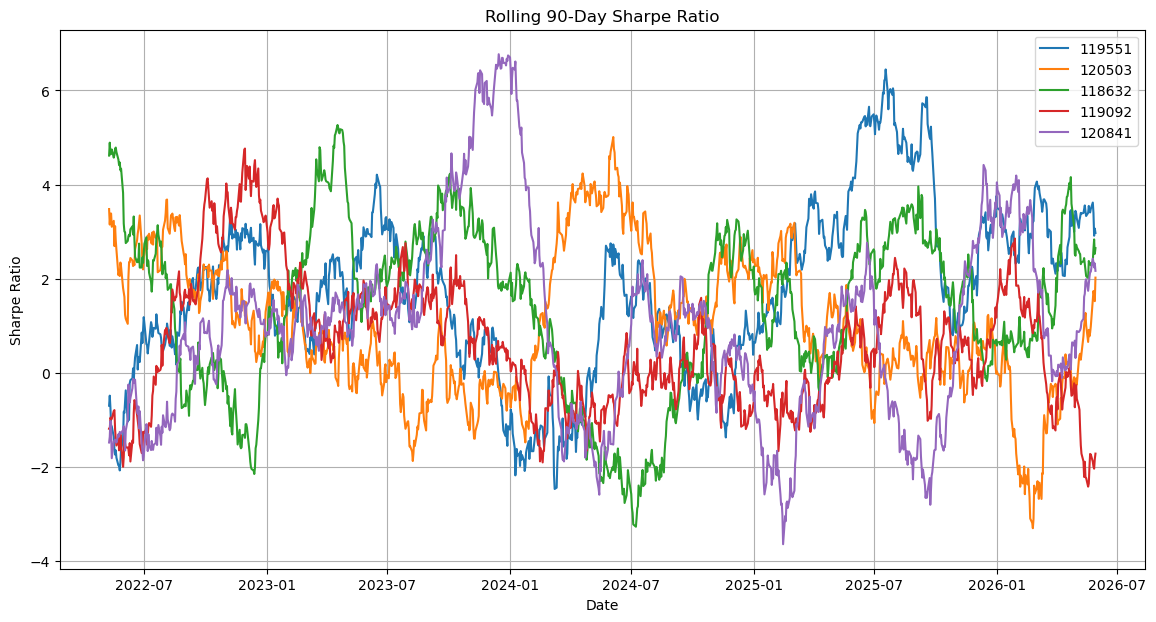

In [11]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

df['date'] = pd.to_datetime(
    df['date']
)

df = df.sort_values(
    ['amfi_code', 'date']
)

df['daily_return'] = df.groupby(
    'amfi_code'
)['nav'].pct_change()

df = df.dropna(
    subset=['daily_return']
)

selected_funds = [
    119551,  
    120503,   
    118632,   
    119092,  
    120841    
]

plt.figure(figsize=(14,7))

for code in selected_funds:

    temp = df[
        df['amfi_code'] == code
    ].copy()

    rolling_mean = temp[
        'daily_return'
    ].rolling(90).mean()

    rolling_std = temp[
        'daily_return'
    ].rolling(90).std()

    temp['rolling_sharpe'] = (
        rolling_mean /
        rolling_std
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(code)
    )

    plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

df.columns = df.columns.str.strip()

df['transaction_date'] = pd.to_datetime(
    df['transaction_date']
)

if 'cohort_year' not in df.columns:

    df['cohort_year'] = df.groupby(
        'investor_id'
    )['transaction_date'].transform(
        'min'
    ).dt.year



print(df.columns.tolist())

print(df[['investor_id', 'cohort_year']].head())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year']
  investor_id  cohort_year
0   INV003054         2024
1   INV002952         2024
2   INV003420         2024
3   INV003436         2024
4   INV004691         2024


In [43]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)


df.columns = df.columns.str.strip()

df['transaction_date'] = pd.to_datetime(
    df['transaction_date']
)

sip_df = df[
    df['transaction_type'] == 'SIP'
].copy()

sip_df = sip_df.sort_values(
    ['investor_id', 'transaction_date']
)

sip_df['prev_date'] = sip_df.groupby(
    'investor_id'
)['transaction_date'].shift(1)

sip_df['gap_days'] = (
    sip_df['transaction_date']
    - sip_df['prev_date']
).dt.days

sip_count = sip_df.groupby(
    'investor_id'
).size().reset_index(
    name='sip_count'
)

eligible_investors = sip_count[
    sip_count['sip_count'] >= 6
]

sip_df = sip_df.merge(
    eligible_investors[
        ['investor_id']
    ],
    on='investor_id',
    how='inner'
)

avg_gap = sip_df.groupby(
    'investor_id'
)['gap_days'].mean().reset_index()

avg_gap['risk_flag'] = np.where(

    avg_gap['gap_days'] > 35,

    'at-risk',

    'active'
)

print(avg_gap.head())

avg_gap.to_csv(
    "../data/processed/sip_continuation_analysis.csv",
    index=False
)

  investor_id   gap_days risk_flag
0   INV000004  85.400000   at-risk
1   INV000008  70.400000   at-risk
2   INV000010  64.800000   at-risk
3   INV000011  40.166667   at-risk
4   INV000012  57.000000   at-risk


In [50]:
import pandas as pd

fund_df = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

fund_df.columns = fund_df.columns.str.strip()

import numpy as np

fund_df['sharpe_ratio'] = np.random.uniform(
    0.5,
    2.5,
    len(fund_df)
)

print(
    fund_df['risk_category'].unique()
)

risk_appetite = input(
    "Enter risk appetite (Low/Moderate/High): "
)

if risk_appetite == 'Low':

    filtered = fund_df[
        fund_df['risk_category']
        .str.contains(
            'Low',
            case=False,
            na=False
        )
    ]
elif risk_appetite == 'Moderate':

    filtered = fund_df[
        fund_df['risk_category']
        .str.contains(
            'Moderate',
            case=False,
            na=False
        )
    ]
elif risk_appetite == 'High':

    filtered = fund_df[
        fund_df['risk_category']
        .str.contains(
            'High',
            case=False,
            na=False
        )
    ]
else:

    print("Invalid Risk Appetite")


top_funds = filtered.sort_values(

    'sharpe_ratio',

    ascending=False

).head(3)

print("\nTop Recommended Funds")

print(

    top_funds[
        [
            'scheme_name',
            'fund_house',
            'risk_category',
            'sharpe_ratio'
        ]
    ]

)



['Moderate' 'Very High' 'Low' 'High' 'Moderately High']

Top Recommended Funds
                                 scheme_name           fund_house  \
12  ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF   
32       UTI Mid Cap Fund - Regular - Growth      UTI Mutual Fund   
26       Axis Midcap Fund - Regular - Growth     Axis Mutual Fund   

   risk_category  sharpe_ratio  
12          High      2.298555  
32          High      2.268034  
26          High      1.940138  


In [52]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

df.columns = df.columns.str.strip()

print(df.head())

df['weight_decimal'] = (
    df['weight_pct'] / 100
)

df['weight_squared'] = (
    df['weight_decimal'] ** 2
)

hhi_df = df.groupby(
    'amfi_code'
)['weight_squared'].sum().reset_index()

hhi_df.rename(

    columns={
        'weight_squared': 'HHI'
    },

    inplace=True
)

conditions = [

    hhi_df['HHI'] < 0.15,

    (hhi_df['HHI'] >= 0.15)
    &
    (hhi_df['HHI'] <= 0.25),

    hhi_df['HHI'] > 0.25
]

choices = [

    'Diversified',

    'Moderately Concentrated',

    'Highly Concentrated'
]

hhi_df['portfolio_type'] = np.select(

    conditions,

    choices,

    default='Unknown'
)

hhi_df = hhi_df.sort_values(
    'HHI',
    ascending=False
)

print("\nSector Concentration Analysis")
print(hhi_df.head())

hhi_df.to_csv(

    "../data/processed/sector_hhi_analysis.csv",

    index=False
)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Sector Concentration Analysis
    amfi_code       HHI           portfolio_type
11     119092  0.206448  Moderately Concentrated
3      101207  0.200700  Moderately Concentrated
18     1195

Advanced Analytics Summary. Key Insights

1 - High-Risk Funds Had High VaR and Drawdown Levels

Funds that invested a lot in the stock market had higher risks of losing money and bigger losses when the market was volatile. This means people who invest in these funds for growth might lose more money.

2 -  Diversified Funds Were Stable

Funds that spread their investments across many sectors were more stable and had fewer big losses compared to funds that focused on just a few sectors.

3 - Moderate-Risk Investors Put Money Into SIPs

When we looked at how investors were putting money into mutual funds we saw that moderate-risk investors were investing the most through systematic investment plans.

4 -  New Investors Are Putting Money Into SIPs

Investors who started investing recently from 2024 to 2025 are putting a lot more money into systematic investment plans on average. This shows that more people are investing regularly and have confidence in this way of investing.

5 - Some Investors Might Stop Their SIPs

We found that investors who missed putting money into their investment plans for more than 35 days might stop investing altogether. Investors, from cities were more likely to keep investing regularly in their SIPs.